# OCT wetAMD Segmentation -- Fine-Tuned Model Evaluation

**Model :** UNet++ EfficientNet-B4  
**Task :** 6-class retinal layer segmentation  
**Purpose :** Evaluation only -- no training or fine-tuning code  
**Research :** Lightweight OCT wetAMD segmentation for edge-device deployment  
**Environment :** Google Colab + Google Drive  

---

### Notebook structure

| Step | Description |
|------|-------------|
| 0 | Install dependencies |
| 1 | Imports and CONFIG |
| 2 | Mount Drive, output directories |
| 3 | Class mapping and helper functions |
| 4 | Dataset loader and dynamic-padding collate |
| 5 | Build model and load fine-tuned checkpoint |
| 6 | Metric functions |
| 7 | GPU warmup |
| 8 | Accuracy evaluation -- Dice, IoU, Pixel Accuracy, Sensitivity, Specificity |
| 9 | Compute load -- FLOPs, Parameters, Memory |
| 10 | Throughput -- FPS and ms/frame |
| 11 | Energy and efficiency estimates |
| 12 | Visualisation panel -- OCT / GT / Pred / Overlay |
| 13 | Save all outputs to Drive |
| 14 | Final summary table |

> **No global resize.** ROI crops keep their native size.  
> Dynamic padding snaps every batch to the nearest multiple of 32  
> (required by EfficientNet-B4's encoder stride).


## Step 0 -- Install Dependencies

In [1]:
!pip install -q segmentation-models-pytorch albumentations
!pip install -q fvcore      # FLOPs counting -- gracefully skipped if unavailable
print("Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Dependencies installed


## Step 1 -- Imports and Configuration

Imports are identical to the fine-tune notebook.  
Only evaluation-specific keys are added to CONFIG.

In [2]:
import os, cv2, json, time, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import pandas as pd
from google.colab import drive

# ── CONFIG ──────────────────────────────────────────────────────────────────
# Edit paths here before running. All other cells are read-only.
CONFIG = {
    # ── Split file (produced by oct_dataset_split.ipynb) ────────────────────
    "test_txt"         : "/content/drive/MyDrive/FYP/data/augmented/test.txt",

    # ── Mask folder (same /crop_oct/ -> /crop_mask/ convention) ─────────────
    "mask_dir"         : "/content/drive/MyDrive/FYP/data/augmented/crop_mask",

    # ── Fine-tuned checkpoint ────────────────────────────────────────────────
    "model_ckpt"       : "/content/drive/MyDrive/FYP/FineTune/finetune_unetpp_roi_best.pth",

    # ── Architecture (must match fine-tune notebook exactly) ─────────────────
    "num_classes"      : 6,

    # ── Evaluation settings ──────────────────────────────────────────────────
    "eval_batch_size"  : 1,    # batch=1 for edge-device latency benchmarking
    "n_warmup"         : 10,   # GPU warmup forward passes before timing
    "timing_repeats"   : 3,    # repeat full-set timing N times, report median

    # ── Output paths (Drive) ─────────────────────────────────────────────────
    "eval_dir"         : "/content/drive/MyDrive/FYP/Evaluation",
    "pred_dir"         : "/content/drive/MyDrive/FYP/Evaluation/pred_masks",
    "viz_dir"          : "/content/drive/MyDrive/FYP/Evaluation/visualisations",
    "metrics_csv"      : "/content/drive/MyDrive/FYP/Evaluation/eval_metrics.csv",
    "summary_json"     : "/content/drive/MyDrive/FYP/Evaluation/eval_summary.json",

    # ── Reproducibility ──────────────────────────────────────────────────────
    "seed"             : 42,
}

NUM_CLASSES = CONFIG["num_classes"]
CLASS_NAMES = ["Background", "Retinal Layer", "PED", "SRF", "IRF", "RPE"]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM total  : {total_vram:.1f} GB")
print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"Batch size  : {CONFIG['eval_batch_size']}  (edge-device benchmarking)")
print(f"Warmup runs : {CONFIG['n_warmup']}")

Device      : cuda
GPU         : Tesla T4
VRAM total  : 15.6 GB
NUM_CLASSES : 6
Batch size  : 1  (edge-device benchmarking)
Warmup runs : 10


## Step 2 -- Mount Google Drive and Create Output Directories

In [4]:
drive.mount("/content/drive")

for d in [CONFIG["eval_dir"], CONFIG["pred_dir"], CONFIG["viz_dir"]]:
    os.makedirs(d, exist_ok=True)
    print(f"  {d}")
print("Drive mounted. Directories ready.")

Mounted at /content/drive
  /content/drive/MyDrive/FYP/Evaluation
  /content/drive/MyDrive/FYP/Evaluation/pred_masks
  /content/drive/MyDrive/FYP/Evaluation/visualisations
Drive mounted. Directories ready.


## Step 3 -- Class Mapping and Helper Functions

Copied verbatim from the fine-tune notebook (Cells 3 and 5).  
`rgb_mask_to_class` and `mask_to_rgb` are byte-for-byte identical.

In [5]:
# Verbatim from fine-tune notebook Cell 3
CLASS_INFO = {
    0: {"name": "Background",    "rgb": (0,   0,   0)},
    1: {"name": "Retinal Layer", "rgb": (255, 0,   255)},  # Magenta
    2: {"name": "PED",           "rgb": (255, 255, 0)},    # Yellow
    3: {"name": "SRF",           "rgb": (255, 0,   0)},    # Red
    4: {"name": "IRF",           "rgb": (0,   0,   255)},  # Blue
    5: {"name": "RPE",           "rgb": (0,   255, 0)},    # Green
}

print("-- Class Mapping ---------------------------------------------------")
for cls_id, info in CLASS_INFO.items():
    r, g, b = info["rgb"]
    print(f"  Class {cls_id}: {info['name']:<18} RGB({r:3d},{g:3d},{b:3d})")
print(f"\nNUM_CLASSES = {NUM_CLASSES}")


# Verbatim from fine-tune notebook Cell 5
def rgb_mask_to_class(mask_bgr, class_info, tolerance=40):
    """Convert a BGR colour mask to an integer class label map (H, W)."""
    mask_rgb  = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    h, w, _   = mask_rgb.shape
    pixels    = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist = np.full(len(pixels), np.inf)
    best_cls  = np.zeros(len(pixels), dtype=np.uint8)
    for cls_id, info in class_info.items():
        ref  = np.array(info["rgb"], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        mask_better = dist < best_dist
        best_dist[mask_better] = dist[mask_better]
        best_cls[mask_better]  = cls_id
    return best_cls.reshape(h, w)


CLASS_COLORS_VIZ = [
    [0,   0,   0  ],   # 0 Background  -- black
    [255, 0,   255],   # 1 Retinal     -- magenta
    [255, 255, 0  ],   # 2 PED         -- yellow
    [255, 0,   0  ],   # 3 SRF         -- red
    [0,   0,   255],   # 4 IRF         -- blue
    [0,   255, 0  ],   # 5 RPE         -- green
]

def mask_to_rgb(mask_np):
    """Integer class map to RGB visualisation array."""
    h, w = mask_np.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        rgb[mask_np == c] = CLASS_COLORS_VIZ[c]
    return rgb

print("\nHelper functions defined: rgb_mask_to_class, mask_to_rgb")

-- Class Mapping ---------------------------------------------------
  Class 0: Background         RGB(  0,  0,  0)
  Class 1: Retinal Layer      RGB(255,  0,255)
  Class 2: PED                RGB(255,255,  0)
  Class 3: SRF                RGB(255,  0,  0)
  Class 4: IRF                RGB(  0,  0,255)
  Class 5: RPE                RGB(  0,255,  0)

NUM_CLASSES = 6

Helper functions defined: rgb_mask_to_class, mask_to_rgb


## Step 4 -- Dataset Loader and Dynamic-Padding Collate

Copied verbatim from the fine-tune notebook (Cells 7 and 9).

Key behaviours preserved:

- `ROIAugDataset` reads paths from `test.txt`, derives each mask path by
  substituting `/crop_oct/` with `/crop_mask/`
- `get_transforms(train=False)` applies normalisation only -- no augmentation
  at evaluation time
- `pad_collate_fn` snaps every batch to the nearest multiple of 32 so the
  EfficientNet-B4 encoder never receives a misaligned spatial dimension
- Images are **never globally resized** -- native crop sizes are preserved


In [6]:
# Verbatim from fine-tune notebook Cell 7
class ROIAugDataset(Dataset):
    """Dataset for ROI translation-augmented OCT crops.

    Reads image paths from a pre-split .txt file.
    Masks are resolved automatically via path substitution.
    Images are returned at their NATIVE size (no global resize).
    """
    def __init__(self, txt_path, class_info, transform=None):
        self.class_info = class_info
        self.transform  = transform
        with open(txt_path, "r") as f:
            self.ids = [line.strip() for line in f if line.strip()]
        if len(self.ids) == 0:
            raise RuntimeError(f"No entries found in {txt_path}")
        print(f"  Loaded {len(self.ids):>5} samples from {os.path.basename(txt_path)}")

    def __len__(self):
        return len(self.ids)

    @staticmethod
    def _mask_path_from_oct(oct_path):
        """Swaps /crop_oct/ to /crop_mask/ -- identical to fine-tune notebook."""
        return oct_path.replace("/crop_oct/", "/crop_mask/")

    def __getitem__(self, idx):
        oct_path  = self.ids[idx]
        mask_path = self._mask_path_from_oct(oct_path)
        img = cv2.imread(oct_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"OCT image not found: {oct_path}")
        mask_bgr = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        if mask_bgr is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        mask = rgb_mask_to_class(mask_bgr, self.class_info)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]        # Tensor (1, H, W)
            mask = aug["mask"].long()  # Tensor (H, W)
        else:
            img  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0) / 255.0
            mask = torch.tensor(mask, dtype=torch.long)
        return img, mask   # img: (1, H, W)   mask: (H, W)


# Verbatim from fine-tune notebook Cell 7 -- train=False at evaluation time
def get_transforms(train=True):
    norm = [
        A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
        ToTensorV2(),
    ]
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.4),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussNoise(p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.GridDistortion(p=0.2),
            A.CLAHE(clip_limit=4.0, p=0.3),
            *norm,
        ])
    return A.Compose(norm)


# Verbatim from fine-tune notebook Cell 9
def pad_to_multiple(x, multiple=32):
    """Return the smallest integer >= x that is divisible by multiple."""
    return int(np.ceil(x / multiple) * multiple)


def pad_collate_fn(batch):
    """Collate variable-size (img, mask) pairs with stride-safe padding.

    EfficientNet-B4 encoder has output_stride=32, so both spatial
    dimensions must be divisible by 32.
    """
    imgs, masks = zip(*batch)
    max_h    = max(img.shape[1] for img in imgs)
    max_w    = max(img.shape[2] for img in imgs)
    target_h = pad_to_multiple(max_h, 32)
    target_w = pad_to_multiple(max_w, 32)
    padded_imgs, padded_masks = [], []
    for img, mask in zip(imgs, masks):
        _, h, w = img.shape
        pad_h   = target_h - h
        pad_w   = target_w - w
        padded_imgs.append( F.pad(img,   (0, pad_w, 0, pad_h), value=0.0))
        padded_masks.append(F.pad(mask,  (0, pad_w, 0, pad_h), value=0))
    return torch.stack(padded_imgs), torch.stack(padded_masks)


# ── Build test dataset and loader only --------------------------------------
print("Loading test dataset ...")
test_ds = ROIAugDataset(
    CONFIG["test_txt"],
    CLASS_INFO,
    transform=get_transforms(train=False),   # normalise only -- no augmentation
)

pin = torch.cuda.is_available()
test_loader = DataLoader(
    test_ds,
    batch_size  = CONFIG["eval_batch_size"],
    shuffle     = False,
    num_workers = 2,
    pin_memory  = pin,
    collate_fn  = pad_collate_fn,
)

print(f"\nTest images  : {len(test_ds)}")
print(f"Test batches : {len(test_loader)}  (batch_size={CONFIG['eval_batch_size']})")

# ── Shape sanity check -------------------------------------------------------
_imgs, _masks = next(iter(test_loader))
print(f"\nSample batch (both dims must be divisible by 32):")
print(f"  imgs  : {tuple(_imgs.shape)}   dtype={_imgs.dtype}")
print(f"  masks : {tuple(_masks.shape)}   dtype={_masks.dtype}")
assert _imgs.shape[2] % 32 == 0 and _imgs.shape[3] % 32 == 0, \
    "Padding failed -- dimensions not divisible by 32!"
print("  H and W both divisible by 32 -- OK")
print(f"  Unique classes in sample masks: {_masks.unique().tolist()}")

Loading test dataset ...
  Loaded   758 samples from test.txt

Test images  : 758
Test batches : 758  (batch_size=1)

Sample batch (both dims must be divisible by 32):
  imgs  : (1, 1, 128, 576)   dtype=torch.float32
  masks : (1, 128, 576)   dtype=torch.int64
  H and W both divisible by 32 -- OK
  Unique classes in sample masks: [0, 1, 2, 3, 4]


## Step 5 -- Build Model and Load Fine-Tuned Checkpoint

The architecture is identical to the fine-tune notebook (Cell 11).  
Only the fine-tuned weights are loaded. The model is set to `eval()` immediately  
and is **never trained or modified** in this notebook.


In [7]:
# Architecture verbatim from fine-tune notebook Cell 11
model = smp.UnetPlusPlus(
    encoder_name          = "efficientnet-b4",
    encoder_weights       = None,          # weights come from checkpoint only
    in_channels           = 1,
    classes               = NUM_CLASSES,
    activation            = None,
    decoder_channels      = (256, 128, 64, 32, 16),
    decoder_use_batchnorm = True,
)
model = model.to(device)

# ── Load fine-tuned checkpoint -----------------------------------------------
ckpt_path = CONFIG["model_ckpt"]
assert os.path.exists(ckpt_path), (
    f"Checkpoint not found:\n  {ckpt_path}\n"
    "Check CONFIG['model_ckpt'] and re-run."
)

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()   # EVALUATION MODE -- frozen BN stats, no dropout

n_params     = sum(p.numel() for p in model.parameters())
ckpt_size_mb = os.path.getsize(ckpt_path) / 1e6

print("-- Model -----------------------------------------------------------")
print(f"  Architecture  : UNet++ EfficientNet-B4")
print(f"  Checkpoint    : {ckpt_path}")
print(f"  Saved epoch   : {ckpt.get('epoch', '?')}")
print(f"  Val Dice ckpt : {ckpt.get('dice', '?')}")
print(f"  Parameters    : {n_params:,}  ({n_params/1e6:.2f}M)")
print(f"  Ckpt size     : {ckpt_size_mb:.1f} MB")
print(f"  Device        : {device}")
print(f"  Mode          : {'train' if model.training else 'eval -- OK'}")

-- Model -----------------------------------------------------------
  Architecture  : UNet++ EfficientNet-B4
  Checkpoint    : /content/drive/MyDrive/FYP/FineTune/finetune_unetpp_roi_best.pth
  Saved epoch   : 55
  Val Dice ckpt : 0.7772065323705857
  Parameters    : 20,812,974  (20.81M)
  Ckpt size     : 84.1 MB
  Device        : cuda
  Mode          : eval -- OK


## Step 6 -- Metric Functions

Copied verbatim from the fine-tune notebook (Cell 13).  
All functions operate on raw logit tensors before argmax, identical to training.

| Function | Description |
|---|---|
| `dice_score` | Mean Dice across all 6 classes |
| `iou_score` | Mean IoU across all 6 classes |
| `per_class_dice` | List of per-class Dice values |
| `per_class_iou` | List of per-class IoU values |
| `pixel_accuracy` | Fraction of correctly classified pixels |
| `sensitivity_specificity` | Mean sensitivity and specificity across classes |


In [8]:
# All metric functions verbatim from fine-tune notebook Cell 13

def dice_score(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        scores.append((2 * inter + smooth) / (p.sum() + t.sum() + smooth))
    return torch.stack(scores).mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append((inter + smooth) / (union + smooth))
    return torch.stack(scores).mean().item()

def per_class_dice(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        scores.append(((2 * inter + smooth) / (p.sum() + t.sum() + smooth)).item())
    return scores

def per_class_iou(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append(((inter + smooth) / (union + smooth)).item())
    return scores

def pixel_accuracy(preds, targets):
    """Fraction of correctly classified pixels."""
    preds   = preds.argmax(dim=1)
    correct = (preds == targets).float().sum()
    total   = torch.tensor(targets.numel(), dtype=torch.float32)
    return (correct / total).item()

def sensitivity_specificity(preds, targets, smooth=1e-6):
    """Mean sensitivity (recall) and specificity across all classes."""
    preds = preds.argmax(dim=1)
    sens_list, spec_list = [], []
    for c in range(NUM_CLASSES):
        tp = ((preds == c) & (targets == c)).float().sum()
        fn = ((preds != c) & (targets == c)).float().sum()
        tn = ((preds != c) & (targets != c)).float().sum()
        fp = ((preds == c) & (targets != c)).float().sum()
        sens_list.append(((tp + smooth) / (tp + fn + smooth)).item())
        spec_list.append(((tn + smooth) / (tn + fp + smooth)).item())
    return float(np.mean(sens_list)), float(np.mean(spec_list))

# ── Sanity check -------------------------------------------------------------
_dp = torch.randn(2, NUM_CLASSES, 64, 64).to(device)
_dm = torch.randint(0, NUM_CLASSES, (2, 64, 64)).to(device)
print(f"dice_score sanity : {dice_score(_dp, _dm):.4f}")
print(f"iou_score  sanity : {iou_score(_dp,  _dm):.4f}")
print("All metric functions defined -- OK")

dice_score sanity : 0.1674
iou_score  sanity : 0.0913
All metric functions defined -- OK


## Step 7 -- GPU Warmup

Before any timing measurement, we run `n_warmup` forward passes that are  
**excluded from all metrics and timing**. Warmup is necessary because:

1. CUDA kernels are JIT-compiled on first use -- first batch is 3-10x slower
2. GPU clocks need to reach operating frequency (thermal ramp-up)
3. VRAM allocator pre-allocates memory, eliminating allocation spikes

Skipping warmup produces inflated latency and underreported FPS figures.


In [9]:
print(f"Running {CONFIG['n_warmup']} GPU warmup forward passes ...")

model.eval()
_it = iter(test_loader)

with torch.no_grad():
    for _wi in range(CONFIG["n_warmup"]):
        try:
            _w_img, _ = next(_it)
        except StopIteration:
            _it = iter(test_loader)
            _w_img, _ = next(_it)
        _ = model(_w_img.to(device))

if torch.cuda.is_available():
    torch.cuda.synchronize()
    alloc_mb = torch.cuda.memory_allocated() / 1e6
    print(f"Warmup complete. VRAM allocated: {alloc_mb:.1f} MB")
else:
    print("Warmup complete (CPU mode).")

Running 10 GPU warmup forward passes ...
Warmup complete. VRAM allocated: 170.5 MB


## Step 8 -- Accuracy Evaluation

Runs the complete test set through the model with `torch.no_grad()`.  
Metrics are accumulated per batch and averaged at the end,  
matching the approach in the fine-tune notebook (Cell 21).

| Metric | Formula | Clinical interpretation |
|--------|---------|-------------------------|
| Dice | 2*TP / (2*TP + FP + FN) | Segmentation overlap quality |
| IoU | TP / (TP + FP + FN) | Stricter overlap (Jaccard index) |
| Pixel Accuracy | correct / total pixels | Raw classification rate |
| Sensitivity | TP / (TP + FN) | Lesion detection recall |
| Specificity | TN / (TN + FP) | Background rejection rate |


In [10]:
# ── Accumulators ------------------------------------------------------------
all_dice      = 0.0
all_iou       = 0.0
all_pix_acc   = 0.0
all_sens      = 0.0
all_spec      = 0.0
all_cls_dice  = [0.0] * NUM_CLASSES
all_cls_iou   = [0.0] * NUM_CLASSES
n_batches     = 0

# Per-image lists for std computation and CSV
img_dice     = []
img_iou      = []
img_pix_acc  = []
img_sens     = []
img_spec     = []
img_cls_dice = []
img_cls_iou  = []

model.eval()
print(f"Evaluating {len(test_ds)} test images  (batch_size={CONFIG['eval_batch_size']})")
print(f"{'#':>6} {'Dice':>8} {'IoU':>8} {'PixAcc':>8} {'Sens':>8} {'Spec':>8}")
print("-" * 50)

with torch.no_grad():
    for batch_idx, (imgs, masks) in enumerate(test_loader):
        imgs  = imgs.to(device)
        masks = masks.to(device)
        preds = model(imgs)

        b_dice           = dice_score(preds, masks)
        b_iou            = iou_score(preds,  masks)
        b_pix            = pixel_accuracy(preds, masks)
        b_sens, b_spec   = sensitivity_specificity(preds, masks)
        b_cls_dice       = per_class_dice(preds, masks)
        b_cls_iou        = per_class_iou(preds,  masks)

        all_dice    += b_dice
        all_iou     += b_iou
        all_pix_acc += b_pix
        all_sens    += b_sens
        all_spec    += b_spec
        for c in range(NUM_CLASSES):
            all_cls_dice[c] += b_cls_dice[c]
            all_cls_iou[c]  += b_cls_iou[c]

        img_dice.append(b_dice)
        img_iou.append(b_iou)
        img_pix_acc.append(b_pix)
        img_sens.append(b_sens)
        img_spec.append(b_spec)
        img_cls_dice.append(b_cls_dice)
        img_cls_iou.append(b_cls_iou)
        n_batches += 1

        if (batch_idx + 1) % 50 == 0 or batch_idx == 0:
            print(f"{batch_idx+1:>6} {b_dice:>8.4f} {b_iou:>8.4f} "
                  f"{b_pix:>8.4f} {b_sens:>8.4f} {b_spec:>8.4f}")

# ── Averages ----------------------------------------------------------------
test_dice    = all_dice    / n_batches
test_iou     = all_iou     / n_batches
test_pix_acc = all_pix_acc / n_batches
test_sens    = all_sens    / n_batches
test_spec    = all_spec    / n_batches
cls_dice_avg = [s / n_batches for s in all_cls_dice]
cls_iou_avg  = [s / n_batches for s in all_cls_iou]

dice_std = float(np.std(img_dice))
iou_std  = float(np.std(img_iou))

# Lesion-only means (excludes Background class 0 which inflates the average)
lesion_dice = float(np.mean(cls_dice_avg[1:]))
lesion_iou  = float(np.mean(cls_iou_avg[1:]))

# ── Print results (same style as fine-tune notebook Cell 21) ----------------
print("\n" + "=" * 60)
print("          TEST SET EVALUATION RESULTS")
print(f"          {len(test_ds)} images   batch_size={CONFIG['eval_batch_size']}")
print("=" * 60)
print(f"  Dice Score       : {test_dice:.4f} +/- {dice_std:.4f}")
print(f"  IoU              : {test_iou:.4f} +/- {iou_std:.4f}")
print(f"  Pixel Accuracy   : {test_pix_acc:.4f}")
print(f"  Sensitivity      : {test_sens:.4f}")
print(f"  Specificity      : {test_spec:.4f}")
print("-" * 60)
print(f"  Lesion Dice (excl. Background) : {lesion_dice:.4f}")
print(f"  Lesion IoU  (excl. Background) : {lesion_iou:.4f}")
print("=" * 60)

BLOCK = chr(9608)   # unicode full block for bar charts
print("\n-- Per-Class Dice --------------------------------------------------")
for name, score in zip(CLASS_NAMES, cls_dice_avg):
    bar = BLOCK * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

print("\n-- Per-Class IoU ---------------------------------------------------")
for name, score in zip(CLASS_NAMES, cls_iou_avg):
    bar = BLOCK * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

Evaluating 758 test images  (batch_size=1)
     #     Dice      IoU   PixAcc     Sens     Spec
--------------------------------------------------
     1   0.6529   0.5537   0.9693   0.8426   0.9890
    50   0.6443   0.6262   0.9595   0.9656   0.9824
   100   0.3240   0.3156   0.8402   0.8235   0.9079
   150   0.7565   0.6601   0.9651   0.8354   0.9782
   200   0.7715   0.7286   0.9872   0.9884   0.9941
   250   0.4450   0.4083   0.8455   0.9736   0.9741
   300   0.7340   0.6684   0.9488   0.9499   0.9866
   350   0.6522   0.5665   0.9595   0.9147   0.9674
   400   0.7214   0.6724   0.9670   0.8834   0.9429
   450   0.8644   0.7820   0.9684   0.9352   0.9851
   500   0.8790   0.7945   0.9596   0.9468   0.9887
   550   0.6587   0.5617   0.9759   0.7633   0.9813
   600   0.8111   0.7054   0.9140   0.8723   0.9761
   650   0.9890   0.9792   0.9952   0.9942   0.9942
   700   0.8281   0.7444   0.9071   0.9620   0.9815
   750   0.9173   0.8614   0.9785   0.9384   0.9911

          TEST SET EV

## Step 9 -- Compute Load Metrics

| Metric | Method |
|--------|--------|
| Parameters | `sum(p.numel() for p in model.parameters())` |
| FLOPs / frame | `fvcore.FlopCountAnalysis` on the median padded crop size |
| Peak VRAM | `torch.cuda.max_memory_allocated()` during one forward pass |
| Checkpoint size | File size of the `.pth` on disk |

FLOPs are computed on the **median padded crop dimensions** observed in the  
test set -- the same size the collate function would produce for a typical batch.


In [12]:
print("-- Compute Load Metrics --------------------------------------------")
print(f"  Total parameters : {n_params:>15,}  ({n_params/1e6:.2f}M)")
print(f"  Checkpoint size  : {ckpt_size_mb:.1f} MB")

# ── Peak VRAM during one forward pass ---------------------------------------
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    model.eval()
    with torch.no_grad():
        _mi, _ = next(iter(test_loader))
        _ = model(_mi.to(device))
    torch.cuda.synchronize()
    peak_vram_mb = torch.cuda.max_memory_allocated() / 1e6
    print(f"  Peak VRAM        : {peak_vram_mb:.1f} MB")
else:
    peak_vram_mb = 0.0
    print("  Peak VRAM        : N/A (CPU mode)")

# ── FLOPs via fvcore --------------------------------------------------------
n_gflops = None
try:
    from fvcore.nn import FlopCountAnalysis

    # Collect padded sizes from a sample of the test set
    print("\n  Sampling test set for median crop size ...")
    _hs, _ws = [], []
    for _ci, (_cimg, _) in enumerate(test_loader):
        _hs.append(_cimg.shape[2])
        _ws.append(_cimg.shape[3])
        if _ci >= 99:
            break

    med_h = pad_to_multiple(int(np.median(_hs)), 32)
    med_w = pad_to_multiple(int(np.median(_ws)), 32)

    _dummy = torch.zeros(1, 1, med_h, med_w).to(device)
    _fl    = FlopCountAnalysis(model, _dummy)
    _fl.unsupported_ops_warnings(False)
    _fl.uncalled_modules_warnings(False)
    n_gflops = _fl.total() / 1e9

    print(f"Median crop size : {int(np.median(_hs))} x {int(np.median(_ws))} "
          f"(padded to {med_h} x {med_w})")
    print(f"  FLOPs / frame    : {n_gflops:.3f} GFLOPs  "
          f"({n_gflops*1000:.1f} MFLOPs)")

except ImportError:
    print("  fvcore not found -- pip install fvcore to enable FLOPs counting")
except Exception as _e:
    print(f"  FLOPs skipped: {_e}")

-- Compute Load Metrics --------------------------------------------
  Total parameters :      20,812,974  (20.81M)
  Checkpoint size  : 84.1 MB
  Peak VRAM        : 231.4 MB

  Sampling test set for median crop size ...
Median crop size : 128 x 416 (padded to 128 x 416)
  FLOPs / frame    : 7.975 GFLOPs  (7974.8 MFLOPs)


## Step 10 -- Throughput Benchmarking (FPS and ms/frame)

### Methodology

1. GPU warmup completed in Step 7 -- CUDA kernels are already compiled
2. Inference runs over the full test set `timing_repeats` times
3. `torch.cuda.synchronize()` is called **before and after** each forward pass
   so the wall-clock timer captures actual GPU execution, not CPU scheduling
4. The **median** across all repeat passes is reported -- more robust than  
   mean against thermal throttling spikes

Batch size = 1 represents worst-case per-frame latency on an edge device.


Timing 3 full-set pass(es) over 758 images ...
  Repeat 1/3  mean 52.32 ms  (19.11 FPS)
  Repeat 2/3  mean 49.29 ms  (20.29 FPS)
  Repeat 3/3  mean 47.70 ms  (20.97 FPS)

-- Throughput Results (3 passes x 758 images) ------
  Mean   latency : 49.77 ms    -->  20.09 FPS
  Median latency : 41.56 ms    -->  24.06 FPS
  Std deviation  : 22.32 ms
  Min / Max      : 24.26 / 214.72 ms
  P95 latency    : 85.68 ms
  P99 latency    : 155.59 ms


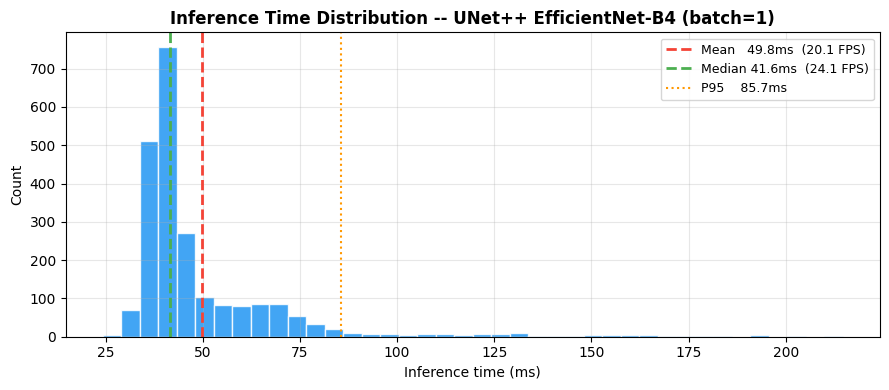

Saved --> /content/drive/MyDrive/FYP/Evaluation/visualisations/timing_histogram.png


In [13]:
REPEATS       = CONFIG["timing_repeats"]
all_run_times = []    # [repeat][image] = ms

model.eval()
print(f"Timing {REPEATS} full-set pass(es) over {len(test_ds)} images ...")

for rep in range(REPEATS):
    run_times = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _  = model(imgs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            run_times.append((time.perf_counter() - t0) * 1000)
    all_run_times.append(run_times)
    print(f"  Repeat {rep+1}/{REPEATS}  mean {np.mean(run_times):.2f} ms"
          f"  ({1000/np.mean(run_times):.2f} FPS)")

flat_ms    = [t for r in all_run_times for t in r]
mean_ms    = float(np.mean(flat_ms))
median_ms  = float(np.median(flat_ms))
std_ms     = float(np.std(flat_ms))
p95_ms     = float(np.percentile(flat_ms, 95))
p99_ms     = float(np.percentile(flat_ms, 99))
fps_mean   = 1000.0 / mean_ms
fps_median = 1000.0 / median_ms

print(f"\n-- Throughput Results ({REPEATS} passes x {len(test_ds)} images) ------")
print(f"  Mean   latency : {mean_ms:.2f} ms    -->  {fps_mean:.2f} FPS")
print(f"  Median latency : {median_ms:.2f} ms    -->  {fps_median:.2f} FPS")
print(f"  Std deviation  : {std_ms:.2f} ms")
print(f"  Min / Max      : {min(flat_ms):.2f} / {max(flat_ms):.2f} ms")
print(f"  P95 latency    : {p95_ms:.2f} ms")
print(f"  P99 latency    : {p99_ms:.2f} ms")

# ── Timing histogram --------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(flat_ms, bins=40, color="#2196F3", edgecolor="white", alpha=0.85)
ax.axvline(mean_ms,   color="#F44336", linestyle="--", linewidth=2,
           label=f"Mean   {mean_ms:.1f}ms  ({fps_mean:.1f} FPS)")
ax.axvline(median_ms, color="#4CAF50", linestyle="--", linewidth=2,
           label=f"Median {median_ms:.1f}ms  ({fps_median:.1f} FPS)")
ax.axvline(p95_ms,    color="#FF9800", linestyle=":",  linewidth=1.5,
           label=f"P95    {p95_ms:.1f}ms")
ax.set_title("Inference Time Distribution -- UNet++ EfficientNet-B4 (batch=1)",
             fontweight="bold")
ax.set_xlabel("Inference time (ms)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
_th_path = os.path.join(CONFIG["viz_dir"], "timing_histogram.png")
plt.savefig(_th_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved --> {_th_path}")

## Step 11 -- Energy and Efficiency Estimates

Direct energy measurement requires hardware power meters (e.g. INA219 on Jetson,  
or `nvidia-smi` with a calibrated shunt). In Colab we use TDP-based estimation:

```
Energy (mJ) = TDP_W * inference_time_s * 1000
```

Three deployment scenarios are reported:

| Scenario | TDP | Represents |
|----------|-----|------------|
| Colab T4 GPU | 70 W | Current benchmarking hardware |
| NVIDIA Jetson Nano | 5-10 W | Primary edge target |
| Raspberry Pi 4 (CPU) | 4-6 W | Minimal edge hardware |

> For publication, replace with measured values from a hardware power meter.


In [14]:
inf_s = median_ms / 1000.0    # use median -- more representative than mean

scenarios = {
    "Colab T4 GPU     (70W TDP)" : 70.0,
    "Jetson Nano       (5W TDP)" :  5.0,
    "Jetson Nano      (10W TDP)" : 10.0,
    "Raspberry Pi 4    (4W TDP)" :  4.0,
    "Raspberry Pi 4    (6W TDP)" :  6.0,
}

print("-- Energy / Efficiency Estimates (TDP-based) -----------------------")
print(f"  Median latency used : {median_ms:.3f} ms  ({fps_median:.2f} FPS)")
print(f"  {'Scenario':<35} {'TDP(W)':>8} {'mJ/frame':>12} {'frames/J':>12}")
print("  " + "-" * 70)

energy_results = {}
for scenario, tdp in scenarios.items():
    mj          = tdp * inf_s * 1000.0
    frames_j    = 1.0 / (tdp * inf_s)
    energy_results[scenario] = {"tdp": tdp, "mj": mj, "fpj": frames_j}
    print(f"  {scenario:<35} {tdp:>8.1f} {mj:>12.3f} {frames_j:>12.1f}")

# ── Attempt nvidia-smi live reading -----------------------------------------
try:
    import subprocess
    r = subprocess.run(
        ["nvidia-smi", "--query-gpu=power.draw", "--format=csv,noheader,nounits"],
        capture_output=True, text=True, timeout=5
    )
    if r.returncode == 0:
        live_w  = float(r.stdout.strip())
        live_mj = live_w * inf_s * 1000.0
        print(f"\n  Live GPU power (nvidia-smi) : {live_w:.1f} W")
        print(f"  Measured mJ/frame           : {live_mj:.3f} mJ  <-- actual")
    else:
        print("\n  nvidia-smi not available -- TDP estimates used above")
except Exception:
    print("\n  nvidia-smi not available -- TDP estimates used above")

# ── Efficiency ratios -------------------------------------------------------
print(f"\n  Dice / ms-per-frame : {test_dice / median_ms:.4f}  (accuracy-speed trade-off)")
if n_gflops:
    print(f"  Dice / GFLOPs       : {test_dice / n_gflops:.4f}  (accuracy-compute trade-off)")

-- Energy / Efficiency Estimates (TDP-based) -----------------------
  Median latency used : 41.556 ms  (24.06 FPS)
  Scenario                              TDP(W)     mJ/frame     frames/J
  ----------------------------------------------------------------------
  Colab T4 GPU     (70W TDP)              70.0     2908.919          0.3
  Jetson Nano       (5W TDP)               5.0      207.780          4.8
  Jetson Nano      (10W TDP)              10.0      415.560          2.4
  Raspberry Pi 4    (4W TDP)               4.0      166.224          6.0
  Raspberry Pi 4    (6W TDP)               6.0      249.336          4.0

  Live GPU power (nvidia-smi) : 32.7 W
  Measured mJ/frame           : 1357.218 mJ  <-- actual

  Dice / ms-per-frame : 0.0188  (accuracy-speed trade-off)
  Dice / GFLOPs       : 0.0979  (accuracy-compute trade-off)


## Step 12 -- Visualisation Panels

### Panel A -- 4-column prediction quality panel

Five samples are selected from the test set: best, 75th percentile, median,  
25th percentile, and worst Dice -- giving a representative view of model behaviour.

| Column | Content |
|--------|---------|
| 1 | Input OCT image (grayscale) |
| 2 | Ground-truth mask (colour-coded) |
| 3 | Predicted mask (colour-coded) |
| 4 | Overlay: OCT + non-background prediction (alpha-blended) |

### Panel B -- Per-class Dice and IoU bar charts  
### Panel C -- Metric distribution histograms


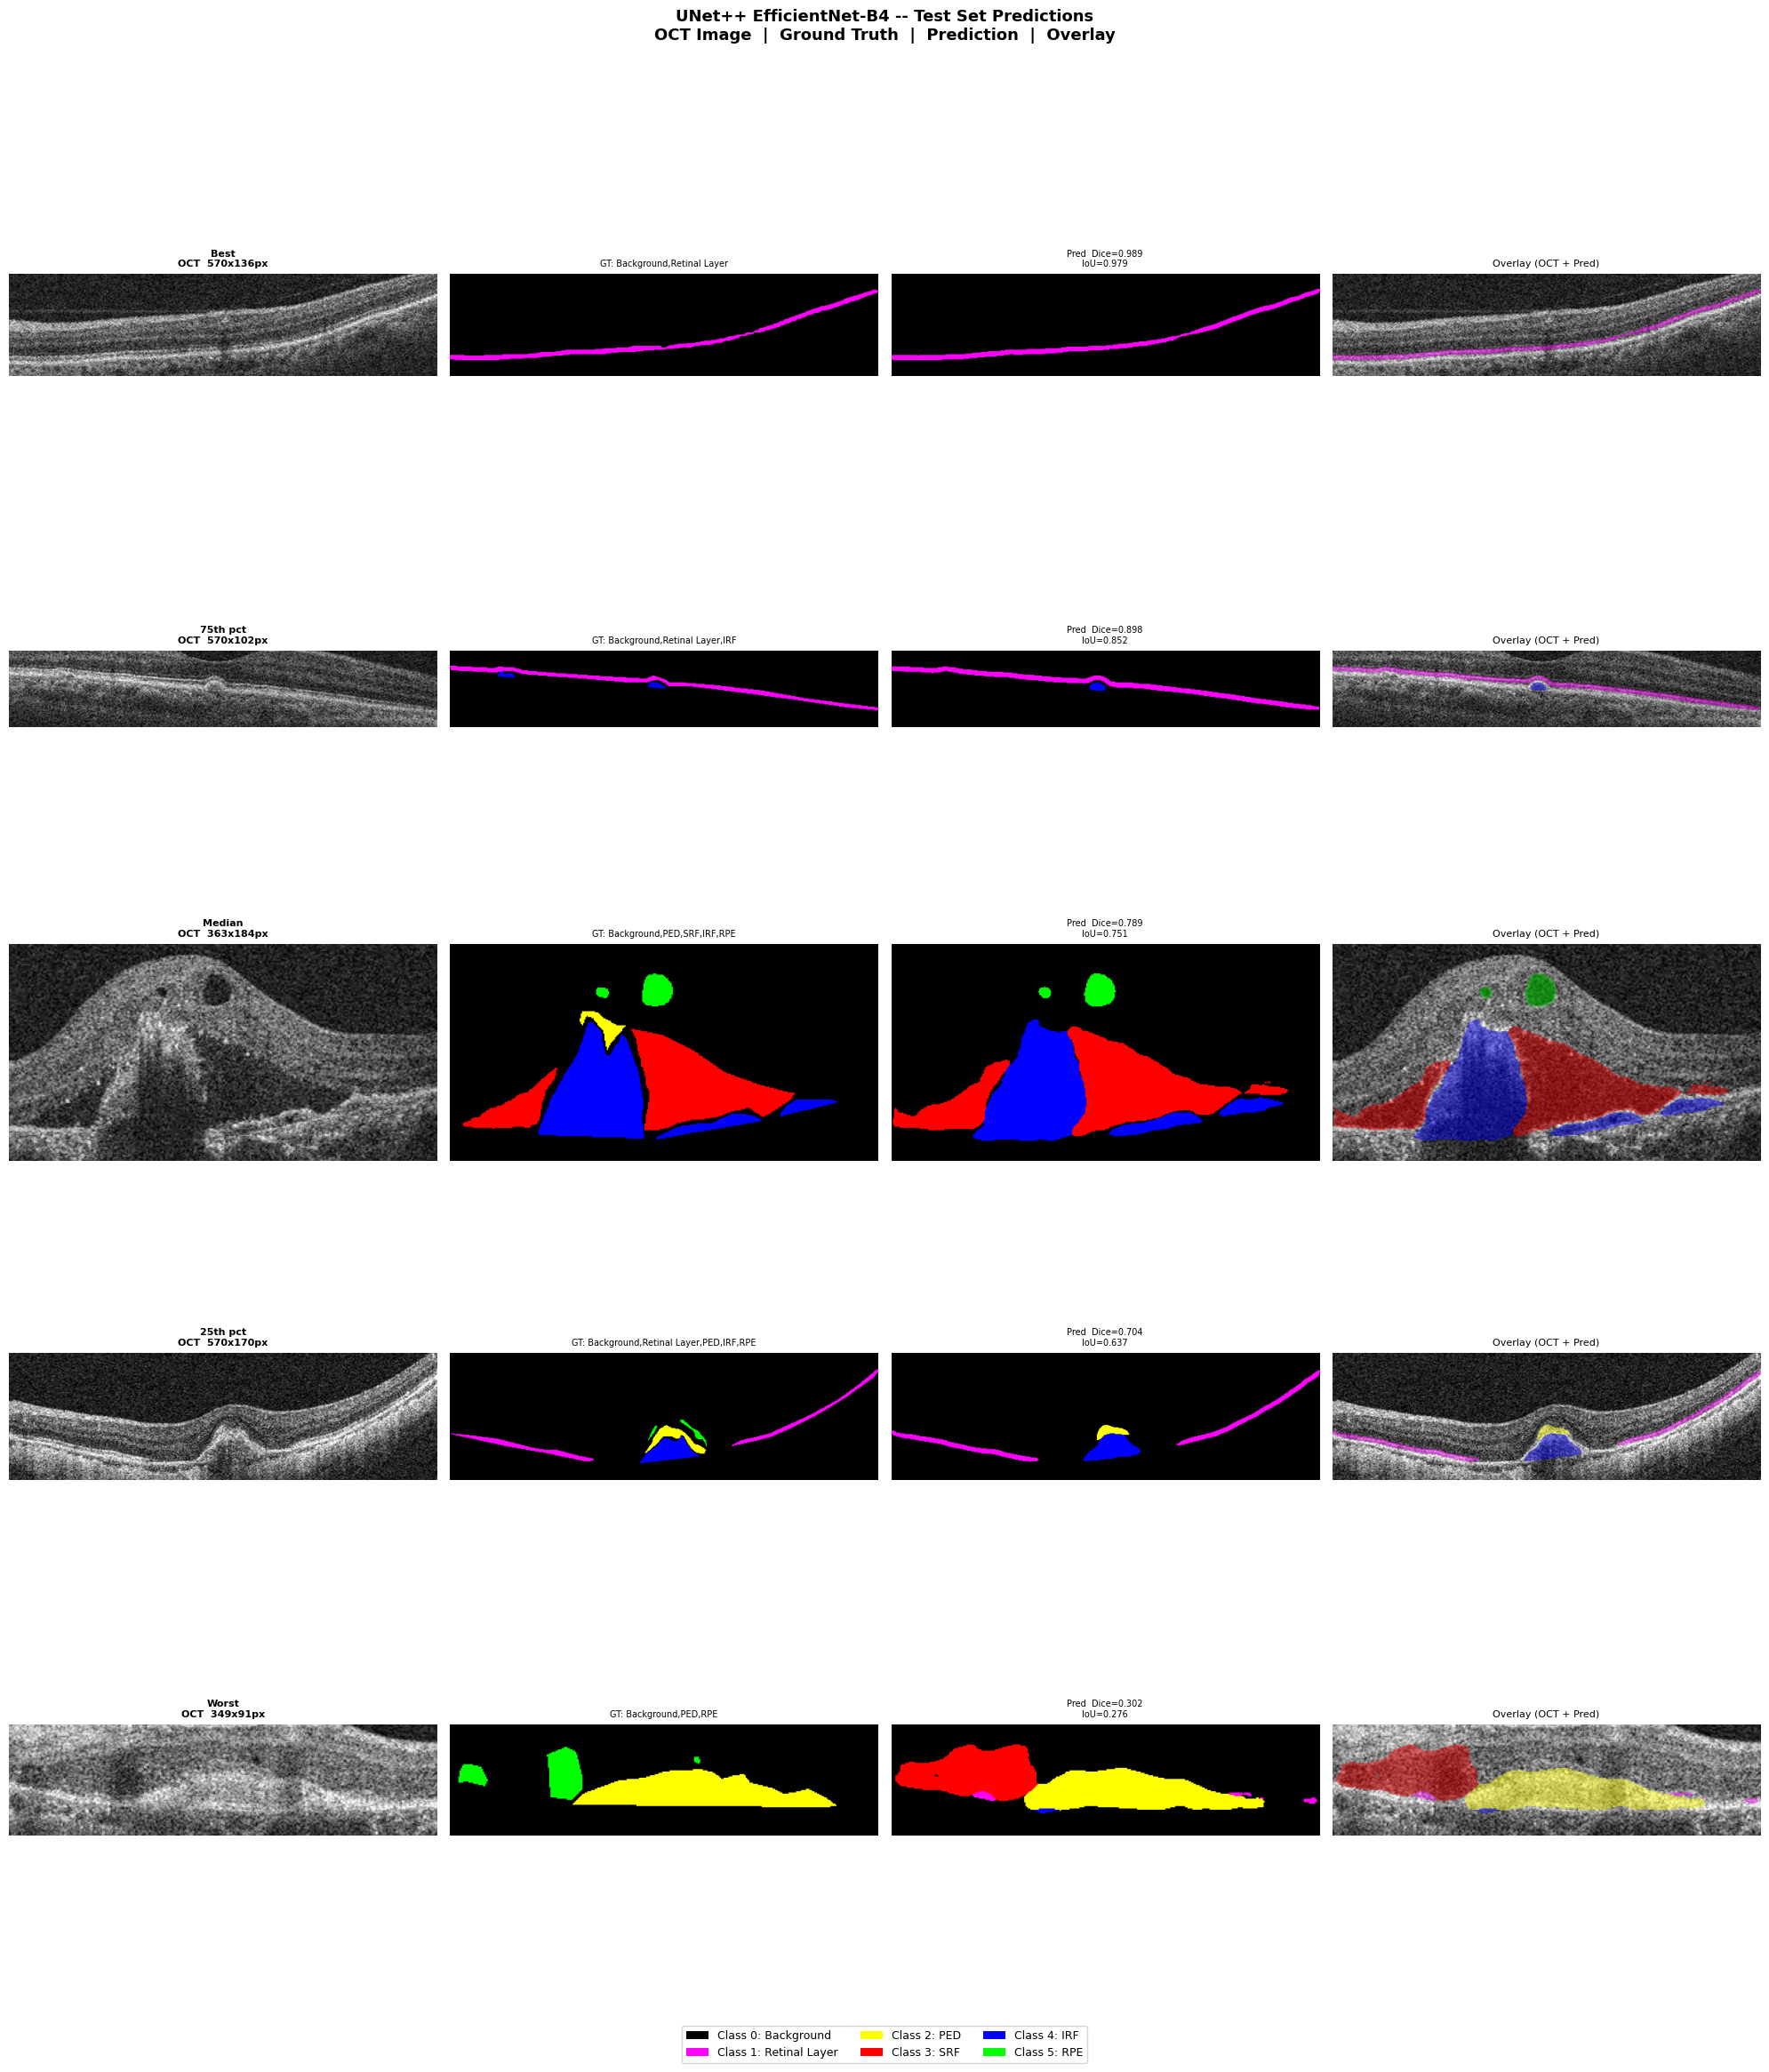

Saved Panel A --> /content/drive/MyDrive/FYP/Evaluation/visualisations/prediction_panel.png


In [15]:
# ── Select representative samples by Dice ranking ---------------------------
sorted_idx = np.argsort(img_dice)
if len(img_dice) >= 5:
    sample_indices = [
        sorted_idx[-1],
        sorted_idx[int(len(sorted_idx) * 0.75)],
        sorted_idx[len(sorted_idx) // 2],
        sorted_idx[int(len(sorted_idx) * 0.25)],
        sorted_idx[0],
    ]
    row_labels = ["Best", "75th pct", "Median", "25th pct", "Worst"]
else:
    sample_indices = list(range(len(img_dice)))
    row_labels     = [f"Sample {i}" for i in sample_indices]

N_SHOW = len(sample_indices)
model.eval()

fig = plt.figure(figsize=(20, 4.5 * N_SHOW))
fig.suptitle(
    "UNet++ EfficientNet-B4 -- Test Set Predictions\n"
    "OCT Image  |  Ground Truth  |  Prediction  |  Overlay",
    fontsize=13, fontweight="bold", y=1.01
)

for ri, (sidx, rlabel) in enumerate(zip(sample_indices, row_labels)):
    oct_path  = test_ds.ids[sidx]
    mask_path = ROIAugDataset._mask_path_from_oct(oct_path)
    img_raw   = cv2.imread(oct_path,  cv2.IMREAD_GRAYSCALE)
    mask_bgr  = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    gt_cls    = rgb_mask_to_class(mask_bgr, CLASS_INFO)

    # Preprocess identical to Dataset __getitem__
    _tf    = get_transforms(train=False)
    _aug   = _tf(image=img_raw, mask=gt_cls)
    _img_t = _aug["image"].unsqueeze(0).to(device)
    _, _, _h, _w = _img_t.shape
    _ph = pad_to_multiple(_h, 32)
    _pw = pad_to_multiple(_w, 32)
    _img_p = F.pad(_img_t, (0, _pw - _w, 0, _ph - _h), value=0.0)

    with torch.no_grad():
        _pred_np = model(_img_p).argmax(dim=1)[0, :_h, :_w].cpu().numpy()

    pred_rgb = mask_to_rgb(_pred_np)
    gt_rgb   = mask_to_rgb(gt_cls)

    # Alpha-blend overlay
    oct_rgb = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2RGB).astype(np.float32)
    fg      = (_pred_np != 0)[..., None]
    overlay = np.where(fg,
                       0.55 * oct_rgb + 0.45 * pred_rgb.astype(np.float32),
                       oct_rgb).clip(0, 255).astype(np.uint8)

    dval = img_dice[sidx]
    ival = img_iou[sidx]

    ax = fig.add_subplot(N_SHOW, 4, ri * 4 + 1)
    ax.imshow(img_raw, cmap="gray")
    ax.set_title(f"{rlabel}\nOCT  {img_raw.shape[1]}x{img_raw.shape[0]}px",
                 fontsize=8, fontweight="bold")
    ax.axis("off")

    ax = fig.add_subplot(N_SHOW, 4, ri * 4 + 2)
    ax.imshow(gt_rgb)
    gt_present = [CLASS_NAMES[c] for c in np.unique(gt_cls) if c < NUM_CLASSES]
    ax.set_title(f"GT: {chr(44).join(gt_present)}", fontsize=7)
    ax.axis("off")

    ax = fig.add_subplot(N_SHOW, 4, ri * 4 + 3)
    ax.imshow(pred_rgb)
    ax.set_title(f"Pred  Dice={dval:.3f}\nIoU={ival:.3f}", fontsize=7)
    ax.axis("off")

    ax = fig.add_subplot(N_SHOW, 4, ri * 4 + 4)
    ax.imshow(overlay)
    ax.set_title("Overlay (OCT + Pred)", fontsize=8)
    ax.axis("off")

legend_elements = [
    Patch(facecolor=np.array(CLASS_COLORS_VIZ[i]) / 255,
          label=f"Class {i}: {CLASS_NAMES[i]}")
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
_pa_path = os.path.join(CONFIG["viz_dir"], "prediction_panel.png")
plt.savefig(_pa_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved Panel A --> {_pa_path}")

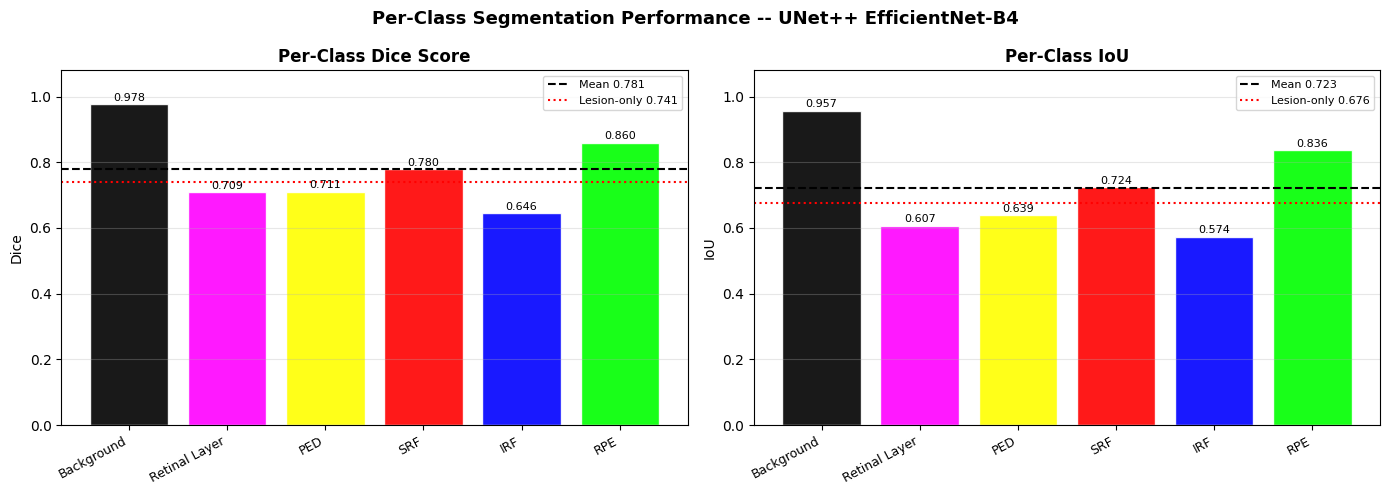

Saved Panel B --> /content/drive/MyDrive/FYP/Evaluation/visualisations/per_class_metrics.png


In [16]:
# ── Panel B -- per-class Dice and IoU bar charts ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-Class Segmentation Performance -- UNet++ EfficientNet-B4",
             fontsize=13, fontweight="bold")

x      = np.arange(NUM_CLASSES)
colors = [np.array(CLASS_COLORS_VIZ[i]) / 255 for i in range(NUM_CLASSES)]

for ax, vals, ylabel, mean_v, lesion_v, title in [
    (axes[0], cls_dice_avg, "Dice", test_dice,  lesion_dice, "Per-Class Dice Score"),
    (axes[1], cls_iou_avg,  "IoU",  test_iou,   lesion_iou,  "Per-Class IoU"),
]:
    ax.bar(x, vals, color=colors, edgecolor="white", alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=28, ha="right", fontsize=9)
    ax.set_ylim([0, 1.08])
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis="y")
    ax.axhline(mean_v,   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean {mean_v:.3f}")
    ax.axhline(lesion_v, color="red",   linestyle=":",  linewidth=1.5,
               label=f"Lesion-only {lesion_v:.3f}")
    ax.legend(fontsize=8)
    for xi, val in enumerate(vals):
        ax.text(xi, val + 0.01, f"{val:.3f}", ha="center", fontsize=8)

plt.tight_layout()
_pb_path = os.path.join(CONFIG["viz_dir"], "per_class_metrics.png")
plt.savefig(_pb_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved Panel B --> {_pb_path}")

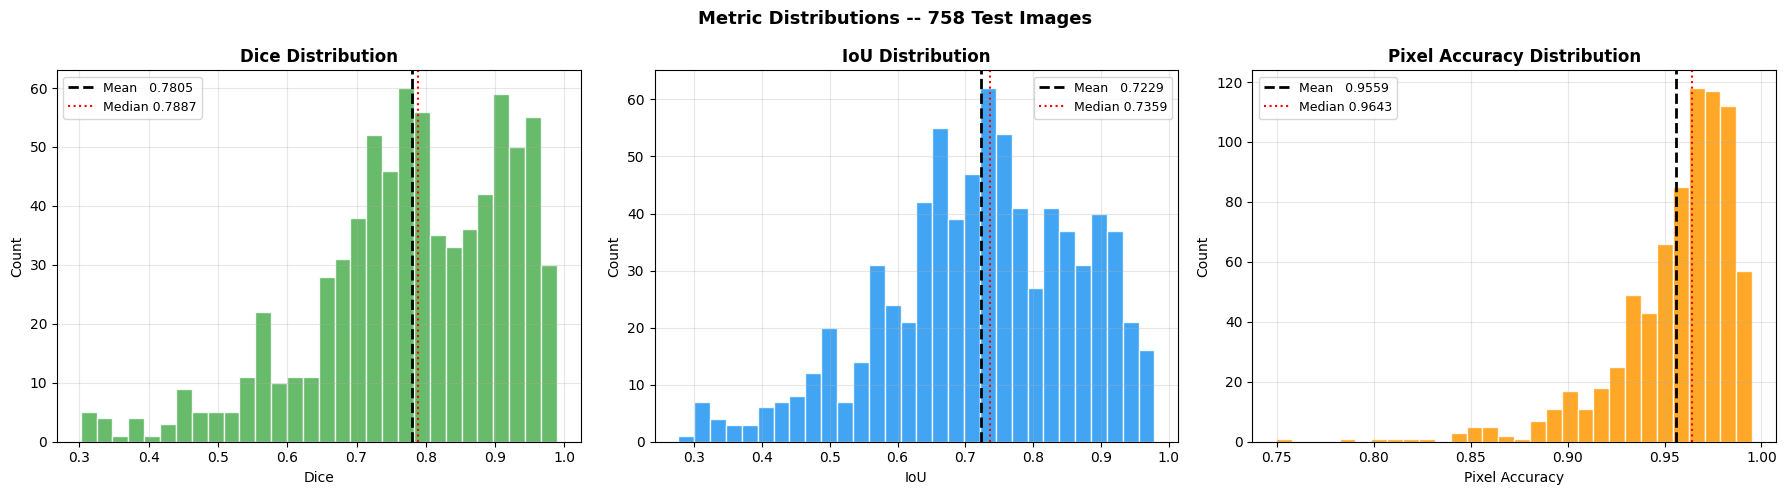

Saved Panel C --> /content/drive/MyDrive/FYP/Evaluation/visualisations/metric_distributions.png


In [17]:
# ── Panel C -- metric distribution histograms --------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Metric Distributions -- {len(test_ds)} Test Images",
             fontsize=13, fontweight="bold")

for ax, vals, label, color, mean_v in [
    (axes[0], img_dice,    "Dice",          "#4CAF50", test_dice),
    (axes[1], img_iou,     "IoU",           "#2196F3", test_iou),
    (axes[2], img_pix_acc, "Pixel Accuracy","#FF9800", test_pix_acc),
]:
    ax.hist(vals, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(mean_v,              color="black", linestyle="--",
               linewidth=2,  label=f"Mean   {mean_v:.4f}")
    ax.axvline(float(np.median(vals)), color="red", linestyle=":",
               linewidth=1.5, label=f"Median {float(np.median(vals)):.4f}")
    ax.set_title(f"{label} Distribution", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
_pc_path = os.path.join(CONFIG["viz_dir"], "metric_distributions.png")
plt.savefig(_pc_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved Panel C --> {_pc_path}")

## Step 13 -- Save All Outputs to Google Drive

In [18]:
# ── 1. Bulk prediction masks ------------------------------------------------
print("Saving prediction masks ...")
model.eval()
saved = 0

with torch.no_grad():
    for imgs, _ in test_loader:
        orig_h = imgs.shape[2]
        orig_w = imgs.shape[3]
        preds_np = model(imgs.to(device)).argmax(dim=1).cpu().numpy()
        for pred in preds_np:
            pred_crop = pred[:orig_h, :orig_w]          # strip padding
            rgb       = mask_to_rgb(pred_crop)
            fname     = os.path.basename(test_ds.ids[saved])
            out_path  = os.path.join(
                CONFIG["pred_dir"],
                os.path.splitext(fname)[0] + "_pred.png"
            )
            cv2.imwrite(out_path, cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
            saved += 1

print(f"Saved {saved} prediction masks --> {CONFIG['pred_dir']}")

# ── 2. Per-image metrics CSV ------------------------------------------------
rows = []
for i, oct_path in enumerate(test_ds.ids):
    row = {
        "fname"         : os.path.basename(oct_path),
        "dice"          : round(img_dice[i],    4),
        "iou"           : round(img_iou[i],     4),
        "pixel_accuracy": round(img_pix_acc[i], 4),
        "sensitivity"   : round(img_sens[i],    4),
        "specificity"   : round(img_spec[i],    4),
    }
    for ci, cname in enumerate(CLASS_NAMES):
        row[f"dice_{cname}"] = round(img_cls_dice[i][ci], 4)
        row[f"iou_{cname}"]  = round(img_cls_iou[i][ci],  4)
    rows.append(row)

df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(CONFIG["metrics_csv"], index=False)
print(f"\nSaved metrics CSV ({len(df_metrics)} rows) --> {CONFIG['metrics_csv']}")
print(df_metrics[["fname","dice","iou","pixel_accuracy","sensitivity","specificity"]]
      .head(5).to_string(index=False))

Saving prediction masks ...
Saved 758 prediction masks --> /content/drive/MyDrive/FYP/Evaluation/pred_masks

Saved metrics CSV (758 rows) --> /content/drive/MyDrive/FYP/Evaluation/eval_metrics.csv
                fname   dice    iou  pixel_accuracy  sensitivity  specificity
         1001_t00.png 0.6529 0.5537          0.9693       0.8426       0.9890
         1007_t00.png 0.6258 0.5597          0.9614       0.9091       0.9779
         1011_t00.png 0.4502 0.3953          0.9082       0.7935       0.9346
1011_t01_r-11_c-2.png 0.4432 0.3902          0.9053       0.7610       0.9262
 1011_t02_r+3_c-7.png 0.3886 0.3567          0.9029       0.7505       0.9098


## Step 14 -- Final Summary Table

Comprehensive evaluation report suitable for inclusion in a research paper.  
Also saved as `eval_summary.json` for easy comparison against other models.


In [19]:
# ── Build summary dict -------------------------------------------------------
summary = {
    # Model identity
    "model"               : "UNet++ EfficientNet-B4",
    "checkpoint"          : CONFIG["model_ckpt"],
    "saved_epoch"         : ckpt.get("epoch", "?"),
    "checkpoint_val_dice" : round(float(ckpt.get("dice", 0)), 4),
    "test_images"         : len(test_ds),
    "eval_batch_size"     : CONFIG["eval_batch_size"],

    # Accuracy metrics
    "dice"                : round(test_dice,    4),
    "dice_std"            : round(dice_std,     4),
    "iou"                 : round(test_iou,     4),
    "iou_std"             : round(iou_std,      4),
    "pixel_accuracy"      : round(test_pix_acc, 4),
    "sensitivity"         : round(test_sens,    4),
    "specificity"         : round(test_spec,    4),
    "lesion_dice"         : round(lesion_dice,  4),
    "lesion_iou"          : round(lesion_iou,   4),

    # Per-class
    "per_class_dice"      : {CLASS_NAMES[i]: round(cls_dice_avg[i], 4)
                             for i in range(NUM_CLASSES)},
    "per_class_iou"       : {CLASS_NAMES[i]: round(cls_iou_avg[i], 4)
                             for i in range(NUM_CLASSES)},

    # Compute load
    "params_M"            : round(n_params / 1e6, 2),
    "gflops_per_frame"    : round(n_gflops, 3) if n_gflops else None,
    "peak_vram_mb"        : round(peak_vram_mb, 1),
    "ckpt_size_mb"        : round(ckpt_size_mb, 1),

    # Throughput
    "mean_ms_per_frame"   : round(mean_ms,   2),
    "median_ms_per_frame" : round(median_ms, 2),
    "p95_ms"              : round(p95_ms,    2),
    "fps_mean"            : round(fps_mean,  2),
    "fps_median"          : round(fps_median,2),

    # Energy (TDP-based)
    "energy_mj_T4_70W"         : round(70.0 * (median_ms/1000) * 1000, 3),
    "energy_mj_JetsonNano_10W" : round(10.0 * (median_ms/1000) * 1000, 3),
    "energy_mj_JetsonNano_5W"  : round( 5.0 * (median_ms/1000) * 1000, 3),
}

with open(CONFIG["summary_json"], "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary JSON --> {CONFIG['summary_json']}")

# ── Print final summary table -----------------------------------------------
SEP  = "=" * 63
DASH = "-" * 63
print("\n" + SEP)
print("    FINAL EVALUATION SUMMARY -- EDGE-DEVICE RESEARCH")
print(SEP)
print(f"  Model          : {summary['model']}")
print(f"  Checkpoint     : epoch {summary['saved_epoch']}   "
      f"Val Dice = {summary['checkpoint_val_dice']}")
print(f"  Test images    : {summary['test_images']}")
print(f"  Eval batch sz  : {summary['eval_batch_size']}")
print(DASH)
print("  ACCURACY METRICS")
print(DASH)
print(f"  Dice Score       : {summary['dice']:.4f} +/- {summary['dice_std']:.4f}")
print(f"  IoU              : {summary['iou']:.4f} +/- {summary['iou_std']:.4f}")
print(f"  Pixel Accuracy   : {summary['pixel_accuracy']:.4f}")
print(f"  Sensitivity      : {summary['sensitivity']:.4f}")
print(f"  Specificity      : {summary['specificity']:.4f}")
print(f"  Lesion Dice      : {summary['lesion_dice']:.4f}  (excl. Background)")
print(f"  Lesion IoU       : {summary['lesion_iou']:.4f}  (excl. Background)")
print(DASH)
print("  PER-CLASS DICE  |  PER-CLASS IoU")
print(DASH)
BLOCK = chr(9608)
for cname in CLASS_NAMES:
    d = summary["per_class_dice"][cname]
    u = summary["per_class_iou"][cname]
    bar = BLOCK * int(d * 20)
    print(f"  {cname:<16}  Dice {d:.4f}   IoU {u:.4f}   {bar}")
print(DASH)
print("  COMPUTE LOAD")
print(DASH)
print(f"  Parameters       : {summary['params_M']:.2f}M")
flops_str = f"{summary['gflops_per_frame']:.3f} GFLOPs" if summary["gflops_per_frame"] else "N/A"
print(f"  FLOPs / frame    : {flops_str}")
print(f"  Peak VRAM        : {summary['peak_vram_mb']:.1f} MB")
print(f"  Checkpoint size  : {summary['ckpt_size_mb']:.1f} MB")
print(DASH)
print("  THROUGHPUT")
print(DASH)
print(f"  Mean  latency    : {summary['mean_ms_per_frame']:.2f} ms/frame  -->  {summary['fps_mean']:.2f} FPS")
print(f"  Median latency   : {summary['median_ms_per_frame']:.2f} ms/frame  -->  {summary['fps_median']:.2f} FPS")
print(f"  P95 latency      : {summary['p95_ms']:.2f} ms")
print(DASH)
print("  ENERGY ESTIMATES (TDP-based)")
print(DASH)
print(f"  T4 GPU   (70W)   : {summary['energy_mj_T4_70W']:.3f} mJ/frame")
print(f"  Jetson   (10W)   : {summary['energy_mj_JetsonNano_10W']:.3f} mJ/frame")
print(f"  Jetson    (5W)   : {summary['energy_mj_JetsonNano_5W']:.3f} mJ/frame")
print(SEP)
print(f"  Summary JSON --> {CONFIG['summary_json']}")
print(f"  Metrics  CSV --> {CONFIG['metrics_csv']}")
print(SEP)

Saved summary JSON --> /content/drive/MyDrive/FYP/Evaluation/eval_summary.json

    FINAL EVALUATION SUMMARY -- EDGE-DEVICE RESEARCH
  Model          : UNet++ EfficientNet-B4
  Checkpoint     : epoch 55   Val Dice = 0.7772
  Test images    : 758
  Eval batch sz  : 1
---------------------------------------------------------------
  ACCURACY METRICS
---------------------------------------------------------------
  Dice Score       : 0.7805 +/- 0.1406
  IoU              : 0.7229 +/- 0.1438
  Pixel Accuracy   : 0.9559
  Sensitivity      : 0.8970
  Specificity      : 0.9772
  Lesion Dice      : 0.7411  (excl. Background)
  Lesion IoU       : 0.6761  (excl. Background)
---------------------------------------------------------------
  PER-CLASS DICE  |  PER-CLASS IoU
---------------------------------------------------------------
  Background        Dice 0.9780   IoU 0.9573   ███████████████████
  Retinal Layer     Dice 0.7087   IoU 0.6074   ██████████████
  PED               Dice 0.7109   Io

---

## Evaluation Complete

### Output files saved to Google Drive

| File | Description |
|------|-------------|
| `Evaluation/pred_masks/*.png` | Per-image colour-coded prediction masks |
| `Evaluation/visualisations/prediction_panel.png` | 4-column best/median/worst panel |
| `Evaluation/visualisations/per_class_metrics.png` | Per-class Dice and IoU bar charts |
| `Evaluation/visualisations/metric_distributions.png` | Dice, IoU, Pixel Accuracy histograms |
| `Evaluation/visualisations/timing_histogram.png` | Inference time distribution |
| `Evaluation/eval_metrics.csv` | Per-image row with all metrics and per-class breakdown |
| `Evaluation/eval_summary.json` | Aggregate report for paper tables |

### Consistency with `finetune_roi_unetpp_epoch80_.ipynb`

| Component | Status |
|-----------|--------|
| `ROIAugDataset` | Verbatim |
| `get_transforms(train=False)` | Verbatim -- normalise only |
| `pad_to_multiple` and `pad_collate_fn` | Verbatim |
| `smp.UnetPlusPlus(...)` architecture | Identical |
| `dice_score`, `iou_score`, `per_class_dice/iou` | Verbatim |
| `pixel_accuracy`, `sensitivity_specificity` | Verbatim |
| `CLASS_INFO`, `CLASS_COLORS_VIZ`, `mask_to_rgb`, `rgb_mask_to_class` | Verbatim |
